In [1]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

# Input file (with or without .npz extension)
FILENAME = "full9-1"

# Input keys to include in the stack plot (up to 12 requested)
KEYS_TO_PLOT = [
    "Bacteroidaceae",
    "Lachnospiraceae",
    "Enterobacteriaceae",
    "Synergistaceae",
    "Prevotellaceae",
    "Ruminococcaceae",
    "Muribaculaceae",
    "Oscillospiraceae",
    "Sutterellaceae",
    "Tannerellaceae",
    "Bifidobacteriaceae",
    "Other_bacteria",
]

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "mocks" and (PROJECT_ROOT.parent / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "pyproject.toml").exists() and (PROJECT_ROOT.parent / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

BASE_DIR = PROJECT_ROOT / "output_files" / "tracked_simulations"
STACK_COLORS = list(plt.get_cmap("tab20").colors[:12])

In [2]:
def resolve_npz_path(filename: str) -> Path:
    candidate = Path(filename)
    if candidate.suffix != ".npz":
        candidate = candidate.with_suffix(".npz")

    if candidate.exists():
        return candidate

    fallback = BASE_DIR / candidate.name
    if fallback.exists():
        return fallback

    raise FileNotFoundError(f"Could not find file: {candidate} or {fallback}")


npz_path = resolve_npz_path(FILENAME)
print(f"Loading: {npz_path}")

with np.load(npz_path) as raw:
    metadata = {}
    if "__state_tracker_metadata__" in raw.files:
        metadata = json.loads(str(raw["__state_tracker_metadata__"].item()))

    tracked = {
        k: raw[k].copy()
        for k in raw.files
        if k != "__state_tracker_metadata__"
    }

available_keys = list(tracked.keys())
print("Available keys:", available_keys)

missing = [k for k in KEYS_TO_PLOT if k not in tracked]
if missing:
    raise KeyError(f"These requested keys are missing in file: {missing}")

# Keep only requested keys that exist, in user-provided order.
selected_keys = [k for k in KEYS_TO_PLOT if k in tracked]

if len(selected_keys) == 0:
    raise ValueError("No keys selected for plotting.")

if len(selected_keys) > 12:
    raise ValueError("Please provide at most 12 keys for this plot.")

key_layers = {}
if metadata:
    keys_meta = metadata.get("keys", [])
    layers_meta = metadata.get("key_layers", [])
    key_layers = {k: int(v) for k, v in zip(keys_meta, layers_meta)}

print("Selected keys:", selected_keys)

Loading: d:\2studiowanie\sem2\Magisterka\Cellular-Automata\output_files\tracked_simulations\full9-1.npz
Available keys: ['substrate', 'biofilm', 'Bacteroidaceae', 'Lachnospiraceae', 'Enterobacteriaceae', 'Synergistaceae', 'Prevotellaceae', 'Ruminococcaceae', 'Muribaculaceae', 'Oscillospiraceae', 'Sutterellaceae', 'Tannerellaceae', 'Bifidobacteriaceae', 'Other_bacteria']
Selected keys: ['Bacteroidaceae', 'Lachnospiraceae', 'Enterobacteriaceae', 'Synergistaceae', 'Prevotellaceae', 'Ruminococcaceae', 'Muribaculaceae', 'Oscillospiraceae', 'Sutterellaceae', 'Tannerellaceae', 'Bifidobacteriaceae', 'Other_bacteria']


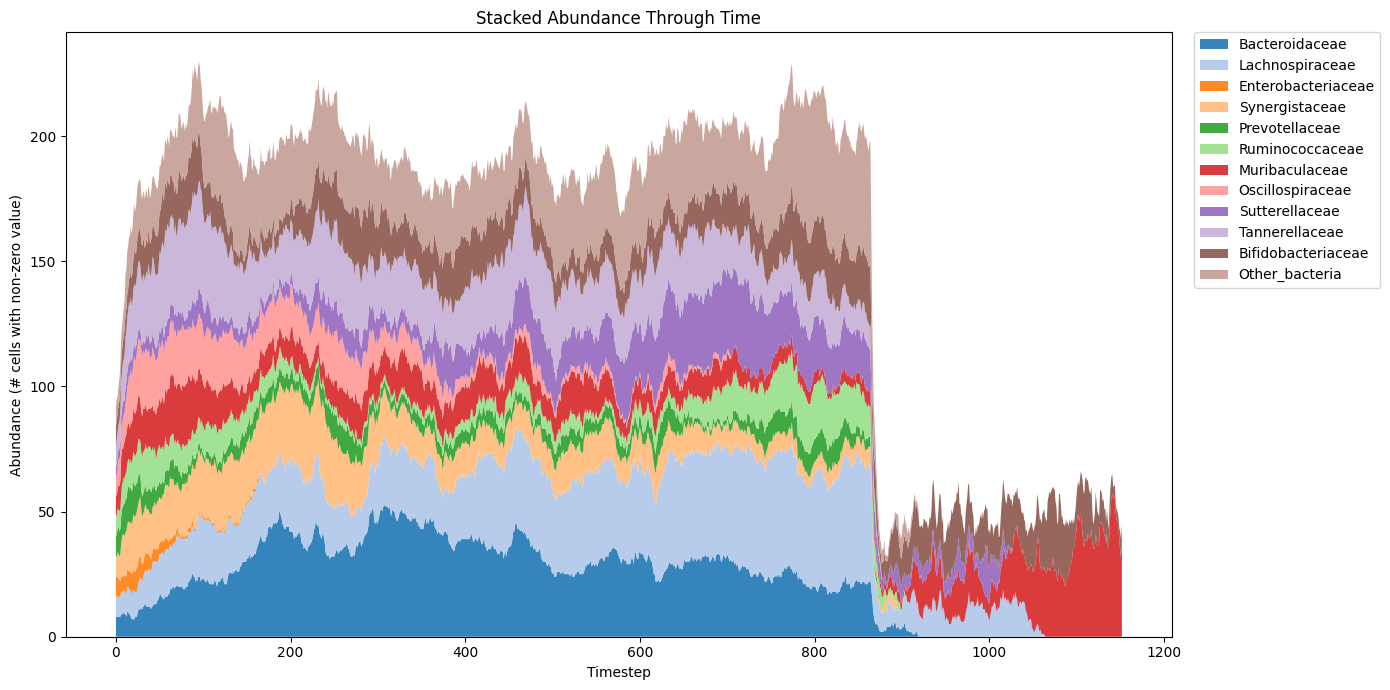

In [3]:
def key_abundance_over_time(arr: np.ndarray, layers: int | None = None) -> np.ndarray:
    """
    arr shape from tracker is typically:
    - no layers: (time, x, y, z)
    - with layers: (time, x, y, z, layers)

    Abundance per timestep = number of spatial cells where value != 0.
    For multi-layer keys, a cell is counted once if ANY layer is non-zero.
    """
    if arr.ndim < 2:
        raise ValueError(f"Expected time + spatial dimensions, got shape {arr.shape}")

    if layers is not None and layers > 1:
        cell_nonzero = np.any(arr != 0, axis=-1)
    else:
        # Fallback for older files without metadata: if rank suggests a layer axis,
        # collapse the last axis to count spatial cells once.
        if layers is None and arr.ndim >= 5:
            cell_nonzero = np.any(arr != 0, axis=-1)
        else:
            cell_nonzero = arr != 0

    # Flatten spatial dims and count non-zero cells for each timestep.
    return cell_nonzero.reshape(cell_nonzero.shape[0], -1).sum(axis=1)


abundance_series = []
for key in selected_keys:
    arr = tracked[key]
    abundance_series.append(key_abundance_over_time(arr, key_layers.get(key)))

abundance_matrix = np.vstack(abundance_series)
time = np.arange(abundance_matrix.shape[1])

plt.figure(figsize=(14, 7))
plt.stackplot(
    time,
    abundance_matrix,
    labels=selected_keys,
    alpha=0.9,
    colors=STACK_COLORS[:len(selected_keys)],
)
plt.title("Stacked Abundance Through Time")
plt.xlabel("Timestep")
plt.ylabel("Abundance (# cells with non-zero value)")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
plt.tight_layout()
plt.show()

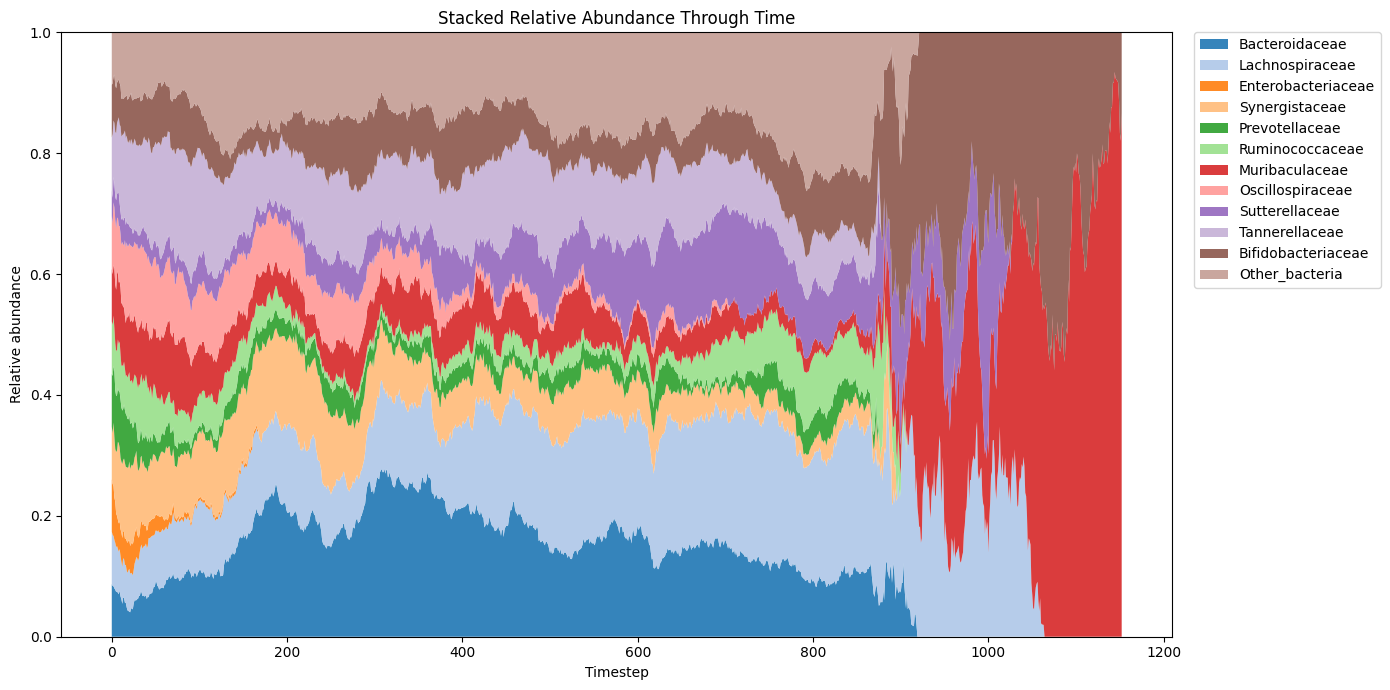

In [4]:
relative_totals = abundance_matrix.sum(axis=0, keepdims=True)
relative_totals = np.where(relative_totals == 0, 1, relative_totals)
relative_matrix = abundance_matrix / relative_totals

plt.figure(figsize=(14, 7))
plt.stackplot(
    time,
    relative_matrix,
    labels=selected_keys,
    alpha=0.9,
    colors=STACK_COLORS[:len(selected_keys)],
)
plt.title("Stacked Relative Abundance Through Time")
plt.xlabel("Timestep")
plt.ylabel("Relative abundance")
plt.ylim(0, 1)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
plt.tight_layout()
plt.show()

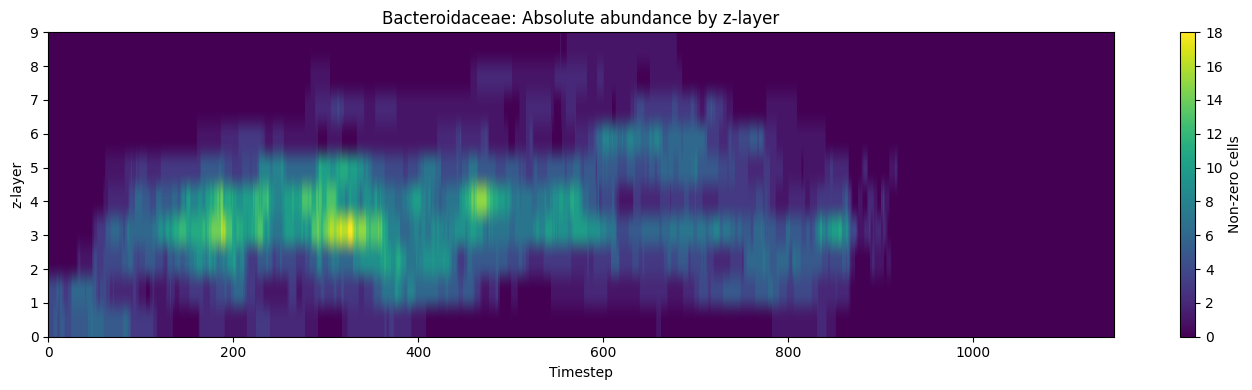

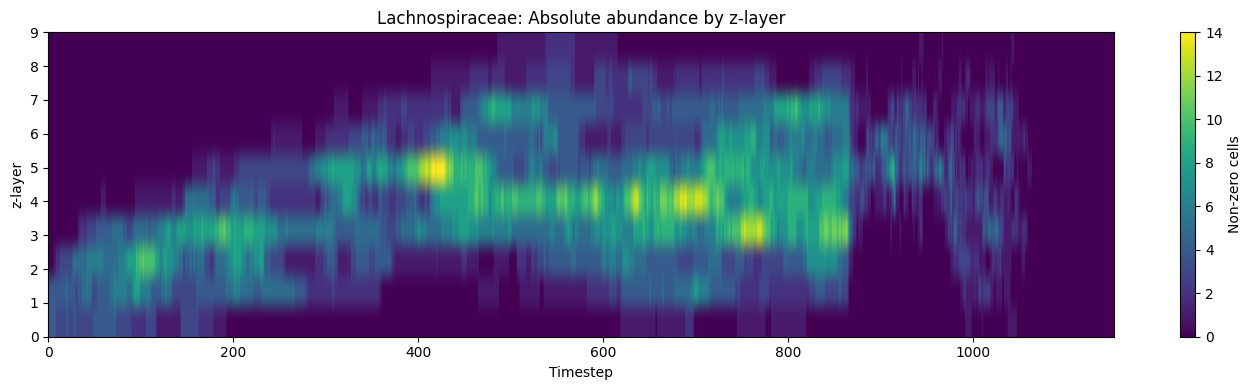

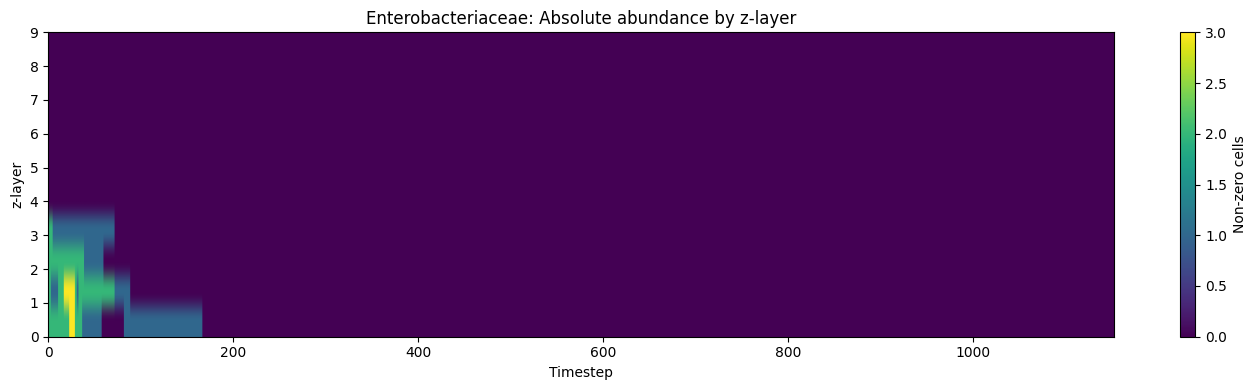

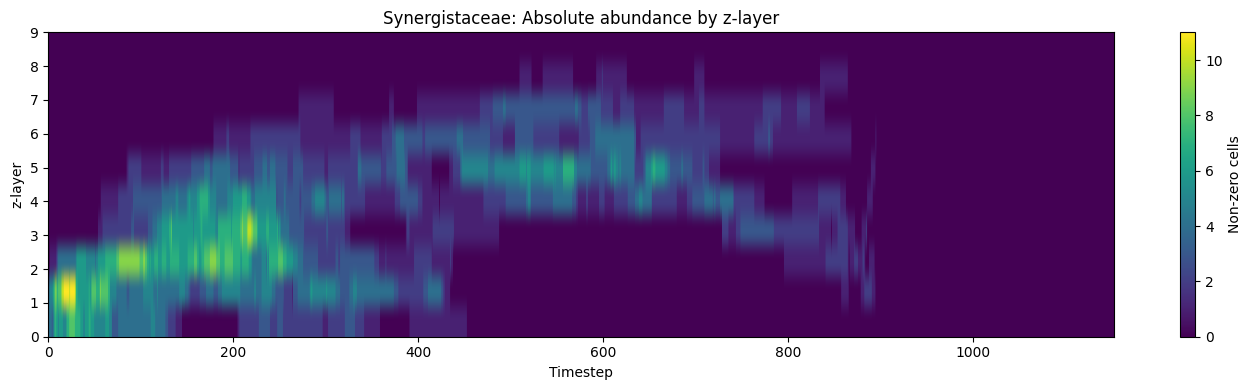

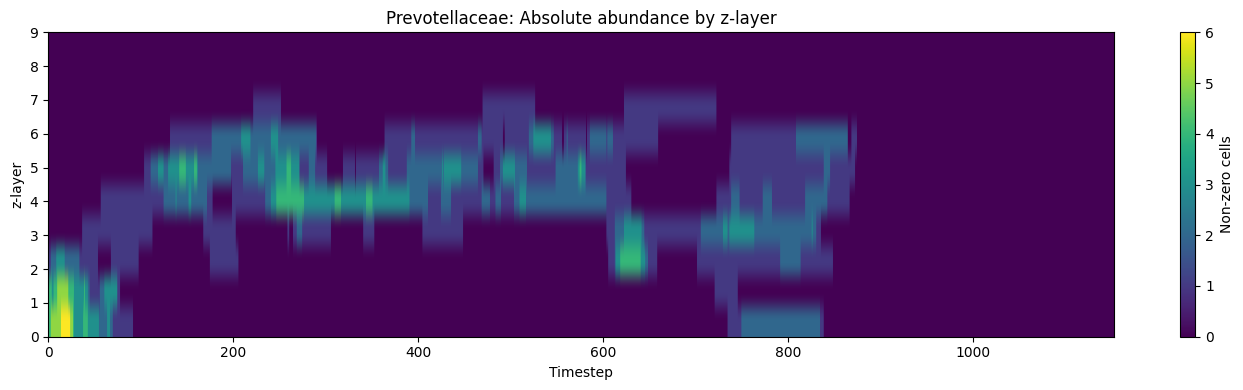

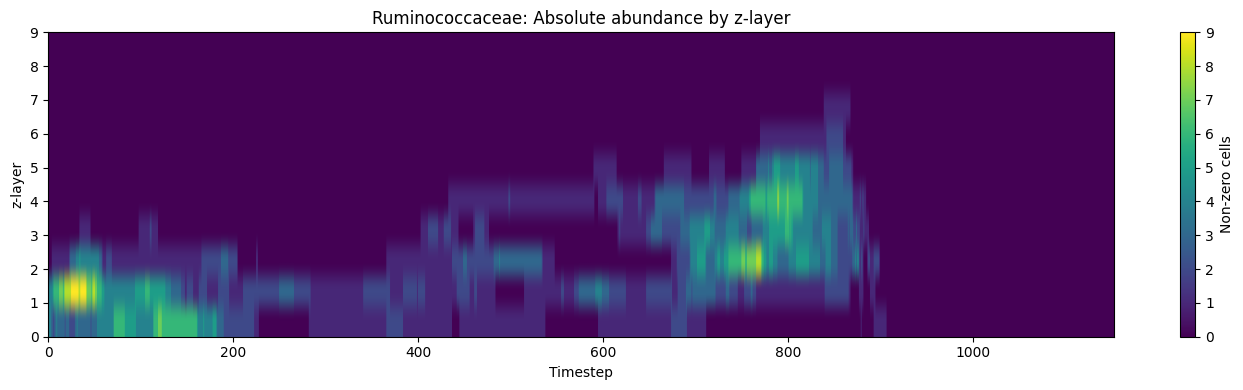

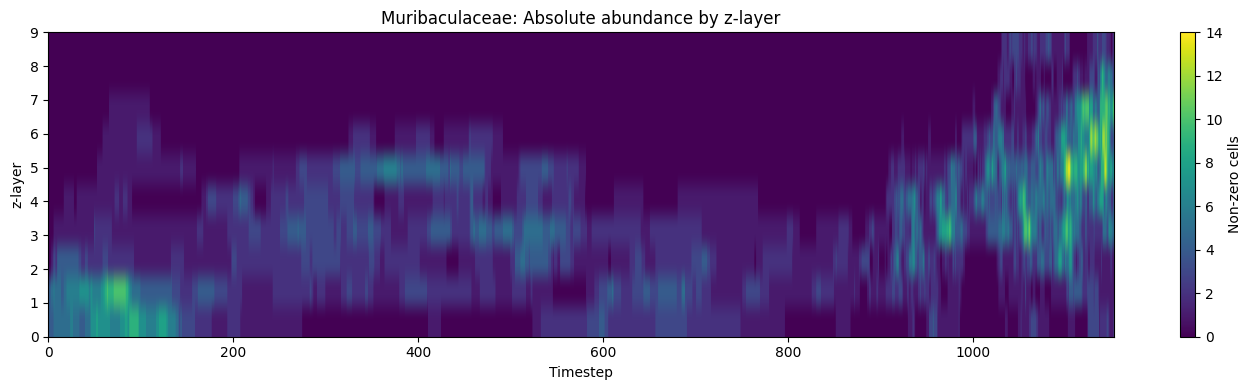

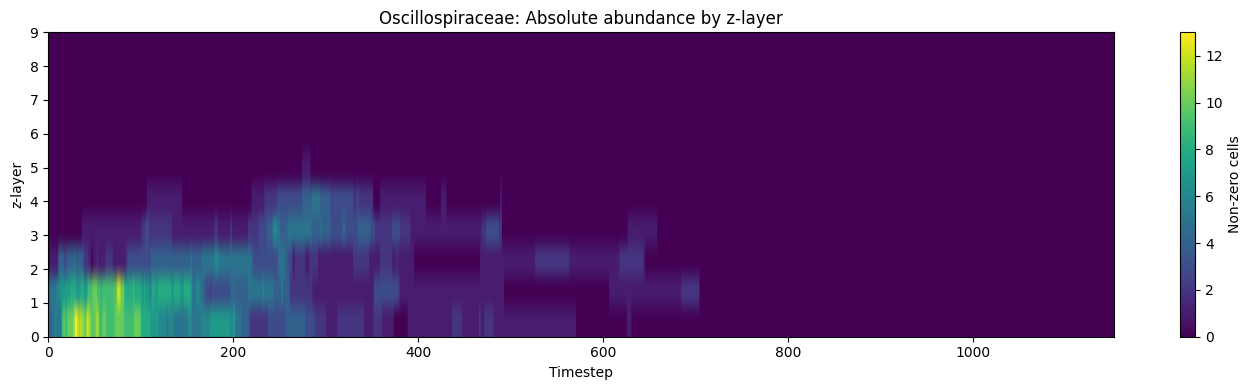

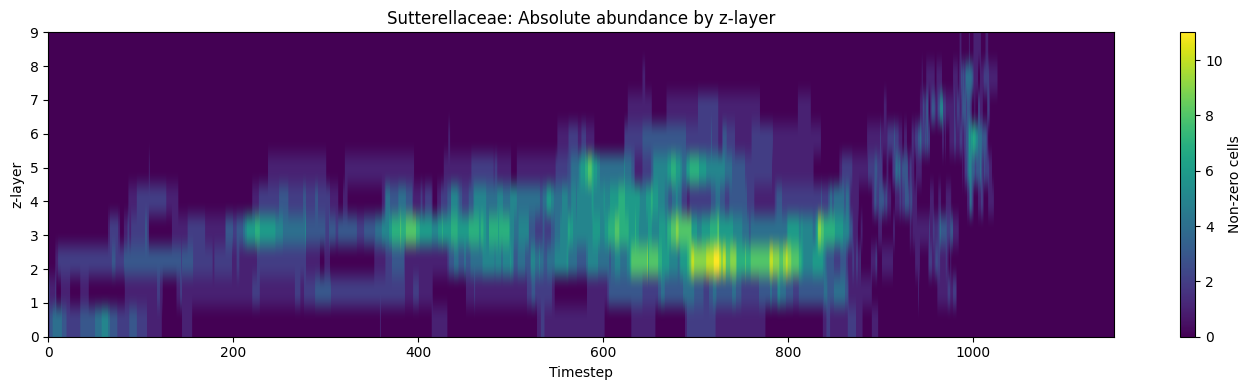

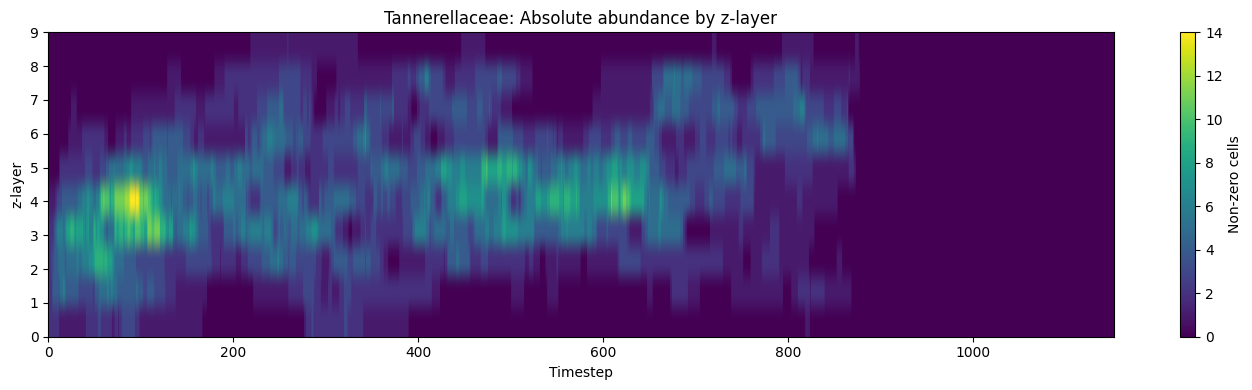

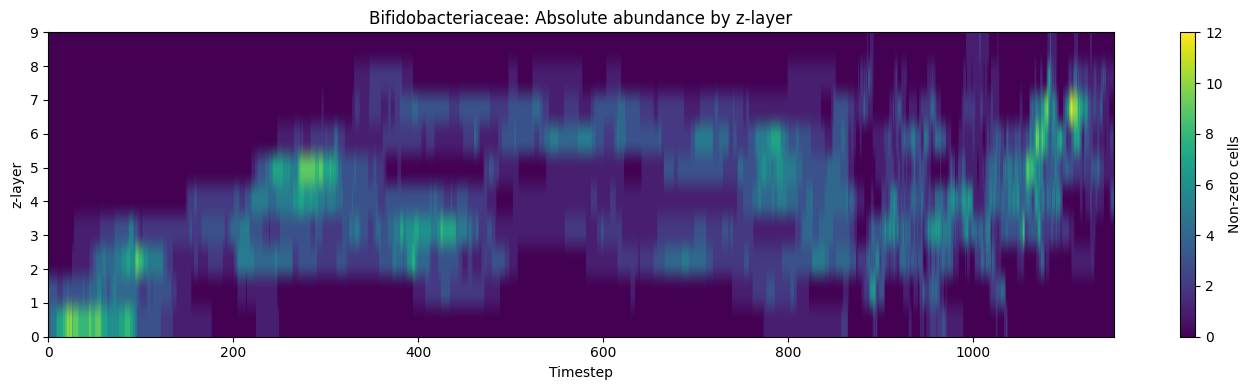

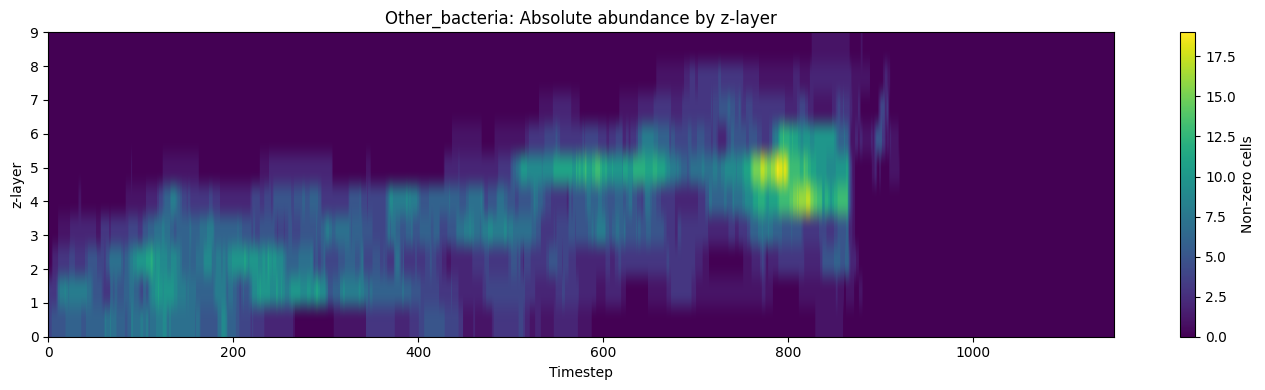

In [5]:
def abundance_by_z_layer(arr: np.ndarray) -> np.ndarray:
    if arr.ndim == 5:
        occupied = np.any(arr != 0, axis=-1)
    elif arr.ndim == 4:
        occupied = arr != 0
    else:
        raise ValueError(f"Expected a 4D or 5D tracked array, got shape {arr.shape}")

    return occupied.sum(axis=(1, 2))


for key in selected_keys:
    series = abundance_by_z_layer(tracked[key])

    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(
        series.T,
        aspect="auto",
        origin="lower",
        cmap="viridis",
        extent=(0, series.shape[0] - 1, 0, series.shape[1] - 1),
    )
    ax.set_title(f"{key}: Absolute abundance by z-layer")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("z-layer")
    fig.colorbar(im, ax=ax, label="Non-zero cells")
    plt.tight_layout()
    plt.show()

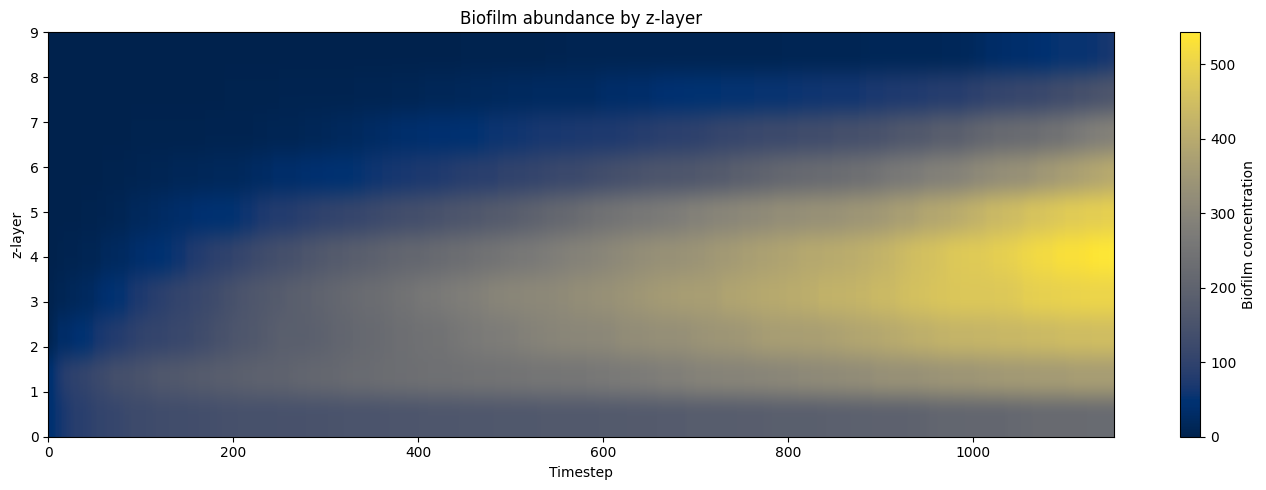

In [6]:
biofilm = tracked.get("biofilm")
if biofilm is None:
    raise KeyError("biofilm field not found in tracked data")

if biofilm.ndim == 5:
    biofilm_total = biofilm.sum(axis=-1)
elif biofilm.ndim == 4:
    biofilm_total = biofilm
else:
    raise ValueError(f"Expected biofilm to be 4D or 5D, got shape {biofilm.shape}")

biofilm_series = biofilm_total.sum(axis=(1, 2))

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(
    biofilm_series.T,
    aspect="auto",
    origin="lower",
    cmap="cividis",
    extent=(0, biofilm_series.shape[0] - 1, 0, biofilm_series.shape[1] - 1),
)
ax.set_title("Biofilm abundance by z-layer")
ax.set_xlabel("Timestep")
ax.set_ylabel("z-layer")
fig.colorbar(im, ax=ax, label="Biofilm concentration")
plt.tight_layout()
plt.show()

(1153, 50, 50, 10, 6)


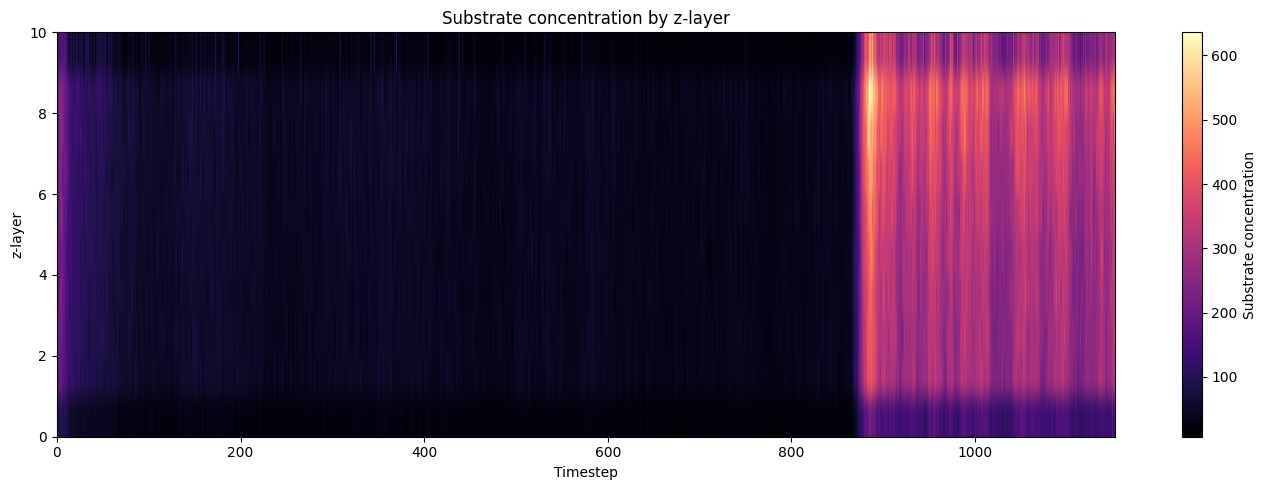

In [7]:
substrate = tracked.get("substrate")
if substrate is None:
    raise KeyError("substrate field not found in tracked data")
print(substrate.shape)
if substrate.ndim == 5:
    substrate_total = substrate.sum(axis=-1)
elif substrate.ndim == 4:
    substrate_total = substrate
else:
    raise ValueError(f"Expected substrate to be 4D or 5D, got shape {substrate.shape}")

substrate_series = substrate_total.sum(axis=(1, 2))

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(
    substrate_series.T,
    aspect="auto",
    origin="lower",
    cmap="magma",
    extent=(0, substrate_series.shape[0], 0, substrate_series.shape[1]),
)
ax.set_title("Substrate concentration by z-layer")
ax.set_xlabel("Timestep")
ax.set_ylabel("z-layer")
fig.colorbar(im, ax=ax, label="Substrate concentration")
plt.tight_layout()
plt.show()